# Introducción a la Ciencia de Datos: Tarea 1


## Introducción
Para este trabajo se utilizará una base de datos abierta que contiene información acerca de artículos de noticias publicados en distintos medios. Los datos abarcan el período comprendido entre enero de 2016 y abril de 2020, e incluyen variables relacionadas al contenido y la identificación de cada artículo, tales como el texto completo, título, autor, URL, temática, fecha y medio de publicación.

El dataset original, All the News 2.1 - Component One, contiene aproximadamente 2,7 millones de artículos provenientes de 27 medios estadounidenses. Debido a la extensión del conjunto de datos, se trabajará con un subconjunto para poder realizar un análisis exploratorio de la producción periodística y su distribución entre diferentes medios a lo largo del tiempo.

## Cargar bibliotecas (dependencias)

In [ ]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
import numpy as np
from datasets import load_dataset


## Descarga del dataset


In [ ]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


all-the-news-2-1-Component-ones-cluster-(…):   0%|          | 0.00/60.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30213 [00:00<?, ? examples/s]

## Lectura de Datos

In [ ]:
# Primeras filas del DataFrame
df.head()
# Información general del DataFrame
df.info()

# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos

In [ ]:
# Problemas de calidad de datos

# Cantidad de filas y columnas
df.shape
# Datos faltantes
df.isnull().sum()
# Datos duplicados
df.duplicated().sum()

In [ ]:
# Cantidad de artículos por medio de prensa
df['publication'].value_counts()

# 5 medios con más artículos
top5 = df['publication'].value_counts().head(5)
top5

# Filtrar df con el top 5 de medios
df_top5 = df[df['publication'].isin(top5.index)].copy()
df_top5.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,None,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,None,The Hill
5,6,6,2019-03-29,2019,3.0,29,None,UPDATE 2-Magellan Health bows to Starboard pre...,"(Updates with new first paragraph, adds backgr...",https://www.cnbc.com/2019/03/29/reuters-americ...,Wires,CNBC
6,7,7,2018-12-04,2018,12.0,4,None,Bank of Montreal's quarterly earnings beat mar...,"TORONTO, Dec 4 (Reuters) - Bank of Montreal on...",https://www.reuters.com/article/bmo-results/ba...,Company News,Reuters


In [ ]:
top5 = df['publication'].value_counts().head(5)
top5

El conjunto de datos analizado contiene 30.213 filas y 12 variables. Como primera etapa, se realizó una exploración general del dataset con el objetivo de comprender su estructura y evaluar la calidad de los datos. En este análisis no se encontraron registros duplicados, por lo que cada fila corresponde a un artículo único.
Sin embargo, se detectaron datos faltantes en algunas variables: author presenta 11.405 valores nulos, section 10.232, article 1.176, mientras que url y publication presentan 141 valores faltantes cada una.
En particular, las columnas author y section muestran una cantidad elevada de datos ausentes, lo que podría limitar futuros análisis vinculados a autores o secciones temáticas.

Posteriormente, se analizó la cantidad de artículos por medio de prensa mediante la frecuencia de la variable publication, y a partir de este análisis se seleccionaron los cinco medios con mayor cantidad de artículos para continuar el trabajo. Los resultados muestran que los medios con más publicaciones son Reuters (9.431 artículos), The New York Times (2.840), CNBC (2.623), The Hill (2.349) y People (1.528), los cuales serán utilizados para el resto del análisis.

Adicionalmente, se calculó la participación de cada uno de estos medios sobre el total de artículos del dataset, el cual está compuesto por 26 medios. En conjunto, los cinco medios seleccionados concentran el 62,2% del total de publicaciones.

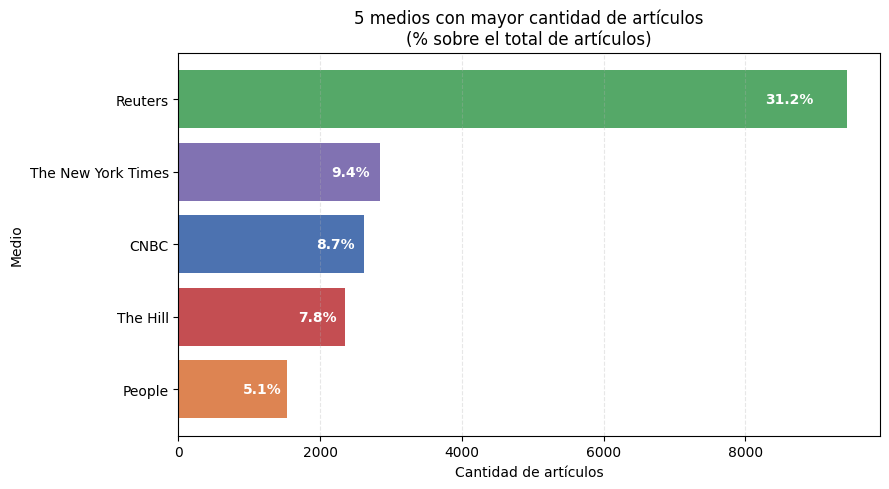

In [ ]:
top5_ordenado = df["publication"].value_counts().head(5).sort_values()
top5_pct = (top5_ordenado / len(df) * 100).round(1)

palette = [
    "#DD8452",
    "#C44E52",
    "#4C72B0",
    "#8172B2",
    "#55A868"
]

plt.figure(figsize=(9,5))

bars = plt.barh(top5_ordenado.index, top5_ordenado.values, color=palette)

plt.title("5 medios con mayor cantidad de artículos\n(% sobre el total de artículos)")
plt.xlabel("Cantidad de artículos")
plt.ylabel("Medio")

for bar, pct in zip(bars, top5_pct):
    plt.text(
        bar.get_width() - (bar.get_width()*0.05),
        bar.get_y() + bar.get_height()/2,
        f"{pct}%",
        va="center",
        ha="right",
        color="white",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## B. Visualización temporal


In [ ]:
#Crear variable year_month que combine
df_top5['year_month'] = (
    df_top5['year'].astype(str) + '-' +
    df_top5['month'].astype(float).astype(int).astype(str).str.zfill(2))

df_top5.head(30)

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication,year_month
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters,2018-02
1,2,2,2018-05-01,2018,5.0,1,None,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC,2018-05
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,None,The Hill,2017-08
5,6,6,2019-03-29,2019,3.0,29,None,UPDATE 2-Magellan Health bows to Starboard pre...,"(Updates with new first paragraph, adds backgr...",https://www.cnbc.com/2019/03/29/reuters-americ...,Wires,CNBC,2019-03
6,7,7,2018-12-04,2018,12.0,4,None,Bank of Montreal's quarterly earnings beat mar...,"TORONTO, Dec 4 (Reuters) - Bank of Montreal on...",https://www.reuters.com/article/bmo-results/ba...,Company News,Reuters,2018-12
8,9,9,2019-05-23 09:30:04,2019,5.0,23,Michael Kolomatsky,Are Beach House Rentals Profitable?,"Calculator Sure, if you choose the right place...",https://www.nytimes.com/2019/05/23/realestate/...,realestate,The New York Times,2019-05
9,10,10,2018-12-30 08:33:24,2018,12.0,30,The Associated Press,Colombia Investigates a Possible Plot to Assas...,"BOGOTÁ, Colombia — Colombia is investigating a...",https://www.nytimes.com/2018/12/30/world/ameri...,world,The New York Times,2018-12
11,12,12,2017-07-14,2017,7.0,14,Josh Delk,McAuliffe jabs Pence over GOP healthcare bill ...,Virginia Gov. Terry McAuliffe (D) included a d...,https://thehill.com/homenews/senate/342124-vir...,None,The Hill,2017-07
12,13,13,2016-09-02,2016,9.0,2,None,Bailout for Italian banks has been 'absolutely...,"Italy's Finance Minister, Pier Carlo Padoan, h...",https://www.cnbc.com/2016/09/02/weak-global-gr...,World Economy,CNBC,2016-09
13,14,14,2019-03-07,2019,3.0,7,Scott Wong and Max Greenwood,Schultz recruiting GOP insiders ahead of possi...,Former Starbucks CEO Howard Schultz has recrui...,https://thehill.com/homenews/campaign/432954-s...,None,The Hill,2019-03


In [ ]:
# Conteo de artículos agrupado por mes y medio de publicación
df_time = df_top5.groupby(['year_month', 'publication']).size().reset_index(name='count')
df_time = df_time.sort_values('year_month')
df_time.head()

,year_month,publication,count
0,2016-01,CNBC,29
1,2016-01,People,32
2,2016-01,Reuters,141
3,2016-01,The Hill,31
4,2016-01,The New York Times,81


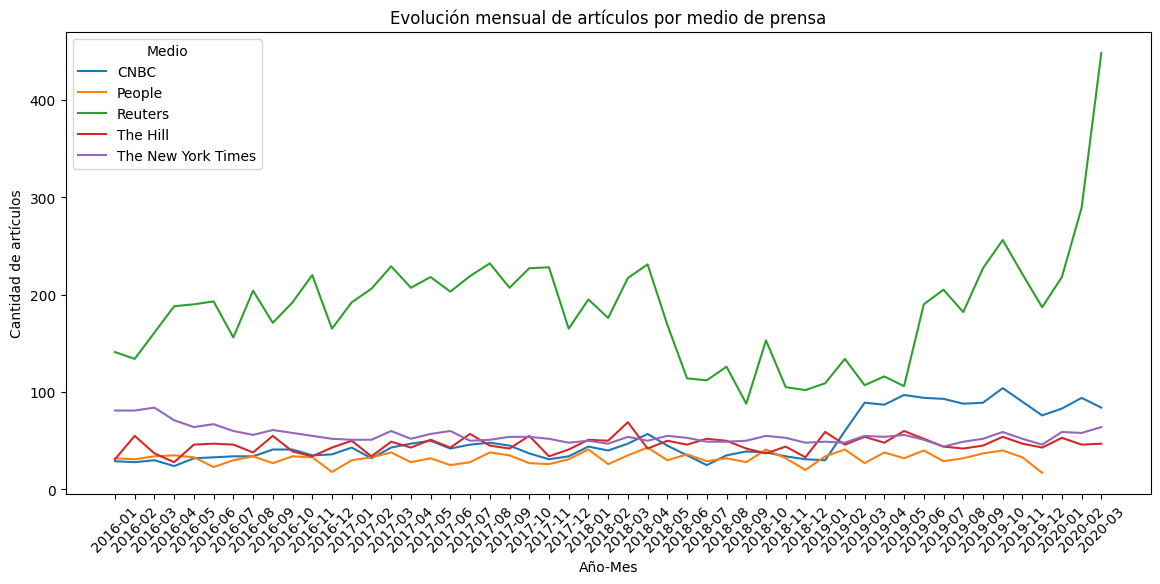

In [ ]:
df_plot = df_time[~(df_time["year_month"] == "2020-04")]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_plot,
    x="year_month",
    y="count",
    hue="publication"
)

plt.xticks(rotation=45)
plt.xlabel("Año-Mes")
plt.ylabel("Cantidad de artículos")
plt.title("Evolución mensual de artículos por medio de prensa")
plt.legend(title="Medio")
plt.show()

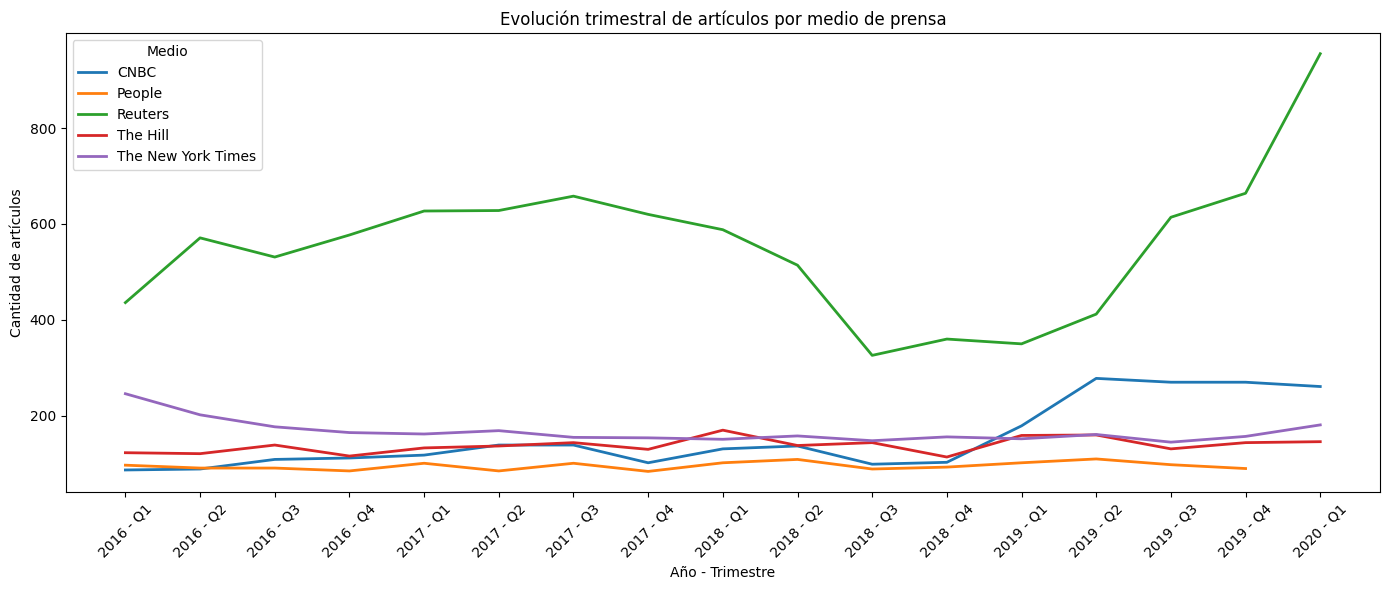

In [ ]:
# Asegurar datetime
df_time["year_month"] = pd.to_datetime(df_time["year_month"])

# Crear trimestre
df_time["year_quarter"] = df_time["year_month"].dt.to_period("Q")

# Agrupar
df_quarter = df_time.groupby(["publication", "year_quarter"])["count"].sum().reset_index()
df_quarter = df_quarter[df_quarter["year_quarter"] != "2020Q2"]

plt.figure(figsize=(14,6))

medios = df_quarter["publication"].unique()

for medio in medios:
    subset = df_quarter[df_quarter["publication"] == medio].sort_values("year_quarter")

    # Formato "Año - Q"
    labels = subset["year_quarter"].apply(lambda x: f"{x.year} - Q{x.quarter}")

    plt.plot(labels, subset["count"], linewidth=2, label=medio)

plt.xticks(rotation=45)
plt.xlabel("Año - Trimestre")
plt.ylabel("Cantidad de artículos")
plt.title("Evolución trimestral de artículos por medio de prensa")
plt.legend(title="Medio")
plt.tight_layout()
plt.show()

Los gráficos muestran diferencias claras entre los medios, tanto a nivel mensual como trimestral. En general, Reuters es el medio con más publicaciones durante todo el período, con valores muy por encima del resto.

Es importante señalar que abril de 2020 no fue considerado en el análisis, debido a que solo se registró un artículo para ese mes. No es posible determinar si esto se debe a datos incompletos o a un error de registro, por lo que se decidió excluirlo para evitar distorsiones en el análisis temporal.
Por otro lado, el medio People no tiene registros durante el año 2020. Sin embargo, el primer trimestre de ese año no fue excluido del análisis, ya que los demás medios sí cuentan con artículos registrados en ese período.

En el gráfico trimestral se observa que Reuters presenta una tendencia relativamente estable entre 2016 y 2018, con algunas variaciones, aunque hacia mediados de 2018 aparece una caída importante en la cantidad de artículos publicados.
No obstante, se observa un aumento en la cantidad de artículos publicados por Reuters a partir de 2019, alcanzando su máximo en 2020-Q1. Este crecimiento coincide con el inicio de la pandemia de COVID-19, lo que sugiere que el contexto global pudo haber influido en un mayor volumen de publicaciones durante ese período.

Por otro lado, CNBC muestra un crecimiento gradual a lo largo del período. Aunque comienza con valores relativamente bajos y estables, desde 2019 se registra un aumento considerable en la cantidad de publicaciones.

The New York Times presenta un comportamiento diferente. En los primeros años muestra una tendencia descendente, pasando de niveles relativamente altos en 2016 a valores más moderados hacia 2018 y 2019.

En el caso de The Hill y People, ambos medios mantienen volúmenes menores y relativamente estables durante todo el período. The Hill muestra algunos picos puntuales, especialmente alrededor de 2018, mientras que People es el medio más constante de todos.

En el gráfico mensual se observan con mayor detalle los cambios mes a mes, destacándose Reuters por su volumen y la magnitud de sus variaciones, que se pierden en el gráfico trimestral por el suavizado.

En conjunto, ambos gráficos permiten identificar diferencias claras en la cobertura de cada medio a lo largo del tiempo. Mientras Reuters y, en menor medida, CNBC muestran un aumento importante en la cantidad de publicaciones hacia el final del período, los demás medios mantienen comportamientos más estables y con menores variaciones.

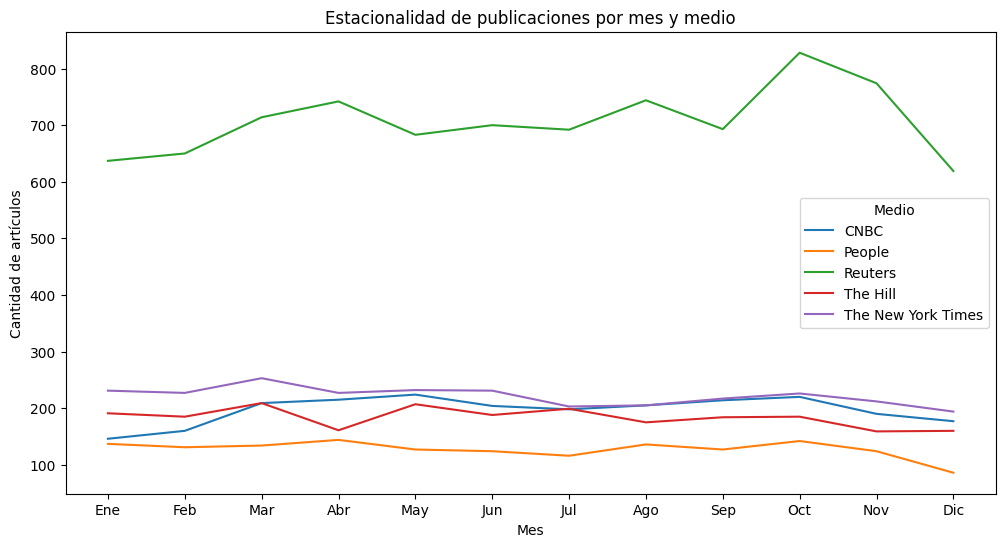

In [ ]:
df_top5['year'] = df_top5['year'].astype(int)
df_clean = df_top5[df_top5['year'] != 2020]

#Se excluye el año 2020 del análisis estacional debido a que los datos solo están disponibles hasta marzo, lo que podría introducir sesgos en la comparación mensual

df_month_media = df_clean.groupby(['month', 'publication']).size().reset_index(name='count')

df_month_media['month'] = pd.to_numeric(df_month_media['month']).astype(int)

df_month_media = df_month_media.sort_values('month')

meses = {
    1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Ago",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}

df_month_media['mes'] = df_month_media['month'].map(meses)

plt.figure(figsize=(12,6))


for medio in df_month_media['publication'].unique():
    subset = df_month_media[df_month_media['publication'] == medio]
    plt.plot(subset['mes'], subset['count'], label=medio)

plt.xlabel("Mes")
plt.ylabel("Cantidad de artículos")
plt.title("Estacionalidad de publicaciones por mes y medio")
plt.legend(title="Medio")
plt.show()


El análisis estacional muestra que Reuters es el medio con mayor cantidad de publicaciones en todos los meses del año, manteniendo niveles muy superiores al resto. Además, presenta aumentos más notorios hacia octubre y noviembre, mientras que en diciembre se observa una disminución.

En cuanto a los demás medios, CNBC registra un aumento gradual hasta mayo, se mantiene estable, alcanza un nuevo pico en octubre y luego disminuye. The Hill presenta picos en marzo y mayo, con una bajada marcada en abril entre ambos. The New York Times muestra variaciones leves a lo largo del año, mientras que People desciende después de octubre.

En general, no se observan patrones estacionales muy marcados, ya que las diferencias entre medios parecen ser más importantes que las variaciones entre meses.

Cabe señalar que el año 2020 fue excluido del análisis estacional debido a que los datos solo están disponibles hasta marzo, lo que podría sesgar la comparación mensual.

## C. Limpieza de texto y conteo de palabras


In [ ]:
texto_completo = " ".join(df_top5.astype(str).values.flatten())

# Obtener todos los caracteres especiales
especiales = sorted(set(
    c for c in texto_completo
    if not c.isalnum() and not c.isspace()
))

print(especiales)

['!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', ':', ';', '<', '=', '>', '?', '@', '[', '\\', ']', '^', '_', '`', '{', '|', '}', '~', '\x7f', '\x80', '\x8d', '\x93', '\x99', '\x9d', '¡', '¢', '£', '¥', '§', '©', '«', '¬', '\xad', '®', '°', '´', '·', '»', '¿', '×', '÷', '́', '̈', '\u200b', '\u200d', '\u200e', '\u200f', '‐', '‑', '–', '—', '―', '‘', '’', '“', '”', '•', '…', '\u202a', '\u202c', '\u202e', '′', '″', '›', '‼', '\u2060', '\u2066', '\u2069', '€', '™', '−', '⎼', '█', '■', '☀', '★', '☐', '☘', '☮', '☺', '♀', '♡', '♥', '♦', '⚡', '✌', '✝', '✡', '✨', '❗', '❤', '➔', '➡', '⬇', '⬥', '、', '。', '《', '》', '【', '】', '️', '\ufeff', '！', '（', '）', '，', '－', '／', '：', '；', '？', '🃏', '🇦', '🇧', '🇨', '🇰', '🇲', '🇴', '🇷', '🇸', '🇺', '🇼', '🌈', '🌊', '🌍', '🌞', '🌟', '🌮', '🌲', '🌸', '🌹', '🌿', '🍀', '🍃', '🍎', '🍑', '🍩', '🍼', '🍾', '🎀', '🎁', '🎂', '🎄', '🎅', '🎈', '🎉', '🎓', '🎵', '🎶', '🎸', '🎾', '🏆', '🏻', '🏼', '🏽', '🏾', '🐧', '🐶', '🐾', '👅', '👇', '👋', '👍', '👏', '👑', '👡', '👦', '👧', '👨', '👩

In [ ]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # Eliminar signos de puntuación
    for punc in especiales:
        result = result.str.replace(punc, " ")

    # Eliminar números
    result = result.str.replace(r'\d+', '', regex=True)

    return result

In [ ]:
# Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"

df_top5['CleanText'] = clean_text(df_top5, 'article')
df_top5[["article", "CleanText"]].head(5)


,article,CleanText
0,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,feb reuters teva pharmaceutical industrie...
1,The head of the Centers for Medicare and Medic...,the head of the centers for medicare and medic...
2,"Benchmark, the venture capital firm that helpe...",benchmark the venture capital firm that helpe...
5,"(Updates with new first paragraph, adds backgr...",updates with new first paragraph adds backgr...
6,"TORONTO, Dec 4 (Reuters) - Bank of Montreal on...",toronto dec reuters bank of montreal on ...


In [ ]:
print("ANTES")
print(df_top5['article'].iloc[0])
print("DESPUÉS")
print(df_top5['CleanText'].iloc[0])

ANTES
Feb 2 (Reuters) - Teva Pharmaceutical Industries Ltd : * EUROPEAN MEDICINES AGENCY (EMA) ACCEPTS FREMANEZUMAB MARKETING AUTHORIZATION APPLICATION Source text for Eikon: Further company coverage:
DESPUÉS
feb   reuters    teva pharmaceutical industries ltd     european medicines agency  ema  accepts fremanezumab marketing authorization application source text for eikon  further company coverage 


Para realizar el conteo de palabras fue necesario aplicar un proceso de limpieza y normalización del texto. En primer lugar, todo el contenido se transformó a minúsculas para evitar que una misma palabra fuese contabilizada de forma diferente según el uso de mayúsculas. Esto permite unificar términos que tienen el mismo significado pero aparecen escritos de distintas maneras, como por ejemplo “Text” y “text”.

Además, se eliminaron signos de puntuación y caracteres especiales, ya que elementos como comas, puntos o símbolos podían generar registros distintos para una misma palabra y afectar el conteo final. La identificación de estos caracteres se realizó filtrando aquellos símbolos que no correspondieran a letras, números o espacios en blanco.

Posteriormente, se eliminaron los números con el fin de reducir ruido en el análisis y obtener un conteo de palabras más consistente, dado que en la mayoría de los casos no aportan información relevante sobre el contenido textual de los artículos.

In [ ]:
# unir todo el texto
texto_total = " ".join(df_top5['CleanText'].astype(str))

# separar en palabras
palabras = texto_total.split()

# contar frecuencias
df_frecuencia = (
    pd.Series(palabras)
    .value_counts()
    .reset_index(name="frecuencia")
    .rename(columns={"index": "palabra"})
)

df_frecuencia.head(20)

,palabra,frecuencia
0,the,452785
1,to,225431
2,of,201347
3,a,195445
4,and,190420
5,in,174581
6,s,115813
7,that,90466
8,on,84655
9,for,81926


In [ ]:
# Búsqueda de palabras

df_frecuencia[df_frecuencia["palabra"] == "inflation"]

,palabra,frecuencia
931,inflation,1127


In [ ]:
#Validar si el conteo está ok

df_frecuencia["frecuencia"].sum()
#8304334

len(" ".join(df_top5["CleanText"].astype(str)).split())
#8304334

8304334

## D. Elección de campos de texto

Si el objetivo es clasificar textos según el medio de prensa al que pertenecen, una opción es trabajar con el cuerpo del artículo. Este contiene mayor volumen de información y un vocabulario más amplio, lo que permite representar de mejor manera el estilo de escritura de cada medio y obtener conteos de palabras más completos.

Por otro lado, si el objetivo fuera identificar temáticas de manera general, se podría trabajar con los títulos de los artículos, ya que suelen resumir el contenido principal en pocas palabras (por ejemplo, “inflation”), facilitando una detección más rápida de los temas.

Finalmente, si se buscara un análisis más específico o detallado, se podría utilizar una combinación del título y el cuerpo del artículo, ya que esto permitiría identificar tanto temáticas generales como subtemas más concretos. Por ejemplo, el título podría indicar una temática general como “inflation”, mientras que el cuerpo del texto permitiría detectar subtemas o causas específicas relacionadas, como “higher production costs”.

## E. Pistas que identifican al medio de prensa

Se analizó si en el texto aparecían pistas que permitieran identificar de forma directa al medio de prensa. En primer lugar, se buscó la presencia del nombre del propio medio dentro de los artículos. Los resultados muestran que esto ocurre con mucha frecuencia en algunos casos, especialmente en Reuters (8724 de 9431 artículos) y The Hill (2335 de 2349 artículos). En CNBC y The New York Times las menciones son menos frecuentes en términos relativos. Para el caso de People, el resultado debe interpretarse con cuidado, ya que “people” es una palabra de uso común en inglés y no necesariamente refiere al medio.

Además, se analizó la presencia de URLs o dominios web dentro del texto, buscando expresiones como “reuters.com” o “nytimes.com”. En general, este tipo de referencias aparece en pocos artículos, por lo que no parece ser una pista tan relevante para identificar el medio.

Por último, se identificaron expresiones repetidas y firmas de cierre. Reuters utiliza muy frecuentemente frases como “Reporting by” y “Editing by”, mientras que en los demás medios estas expresiones son mucho menos comunes. Este tipo de estructuras funciona como una marca muy clara del medio de origen.

En consecuencia, se considera conveniente eliminar o reducir el impacto de estas pistas durante el preprocesamiento. De lo contrario, un modelo podría identificar el medio simplemente a partir de referencias explícitas, URLs o plantillas repetidas, en lugar de aprender diferencias reales en el estilo de escritura o contenido de los artículos.

In [ ]:
# Pistas que identifiquen directamente al medio de prensa

for medio in df_top5['publication'].unique():
    articulos_del_medio = df_top5[df_top5['publication'] == medio]
    cuenta = articulos_del_medio['article'].str.contains(medio, case=False, na=False).sum()
    total = len(articulos_del_medio)
    print(f"{medio}: {cuenta} de {total} artículos contienen la palabra '{medio}'")

In [ ]:
import re

# Diccionario que mapea cada medio con el dominio que esperás encontrar
dominios = {
    'Reuters': 'reuters.com',
    'CNBC': 'cnbc.com',
    'The Hill': 'thehill.com',
    'The New York Times': 'nytimes.com',
    'People': 'people.com'
}

for medio, dominio in dominios.items():
    articulos = df_top5[df_top5['publication'] == medio]
    cuenta = articulos['article'].str.contains(dominio, case=False, na=False).sum()
    total = len(articulos)
    print(f"{medio}: '{dominio}' aparece en {cuenta} de {total} artículos")

In [ ]:
# Cierres comunes
patrones = ['Reporting by', 'Editing by', 'Additional reporting',
            'Read more at', 'Follow us', 'Subscribe to']

for patron in patrones:
    print(f"\n'{patron}':")
    cuenta = df_top5.groupby('publication')['article'].apply(
        lambda x: x.str.contains(patron, case=False, na=False).sum()
    )
    print(cuenta)

## F. Restricción por sección o período temporal
Restringir el análisis a artículos de una misma sección temática o a un período temporal acotado puede ser útil para reducir el efecto del tema en una futura clasificación por medio. Si cada medio cubre temas diferentes, existe el riesgo de que el modelo aprenda a asociar ciertos temas o palabras con un medio específico, en lugar de identificar características propias de su estilo de escritura.

Trabajar con una misma sección temática permitiría comparar a los medios en un contexto más homogéneo, obligando al modelo a enfocarse más en cómo escribe cada medio y no tanto en sobre qué escribe. Del mismo modo, limitar el período temporal podría evitar diferencias asociadas a acontecimientos particulares de ciertos años.

Sin embargo, esta decisión también tiene desventajas. Restringir el análisis reduce la cantidad de datos disponibles. Además, la selección de temas y la cobertura de ciertos eventos también forman parte de la identidad de un medio, por lo que eliminar ese componente podría hacer que se pierda información relevante.

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio

In [ ]:
df_words = df_top5.copy()

df_words["words"] = df_words["CleanText"].astype(str).str.split()

df_exploded = df_words.explode("words")

In [ ]:
df_counts = (
    df_exploded
    .groupby(["publication", "words"])
    .size()
    .reset_index(name="frequency")
)

In [ ]:
top_words = (
    df_counts
    .sort_values(["publication", "frequency"], ascending=[True, False])
    .groupby("publication")
    .head(10)
    .reset_index(drop=True)
)
print(top_words)

           publication words  frequency
0                 CNBC   the      65914
1                 CNBC    to      34794
2                 CNBC    of      28466
3                 CNBC     a      27720
4                 CNBC   and      26904
5                 CNBC    in      25371
6                 CNBC     s      19810
7                 CNBC  that      14384
8                 CNBC    on      12743
9                 CNBC   for      12055
10              People   the      30451
11              People    to      16837
12              People   and      16750
13              People     a      15103
14              People    of      12067
15              People    in      11411
16              People     s       9466
17              People     i       8838
18              People  that       7239
19              People    on       6770
20             Reuters   the     132227
21             Reuters    to      69039
22             Reuters    in      60171
23             Reuters    of      59542


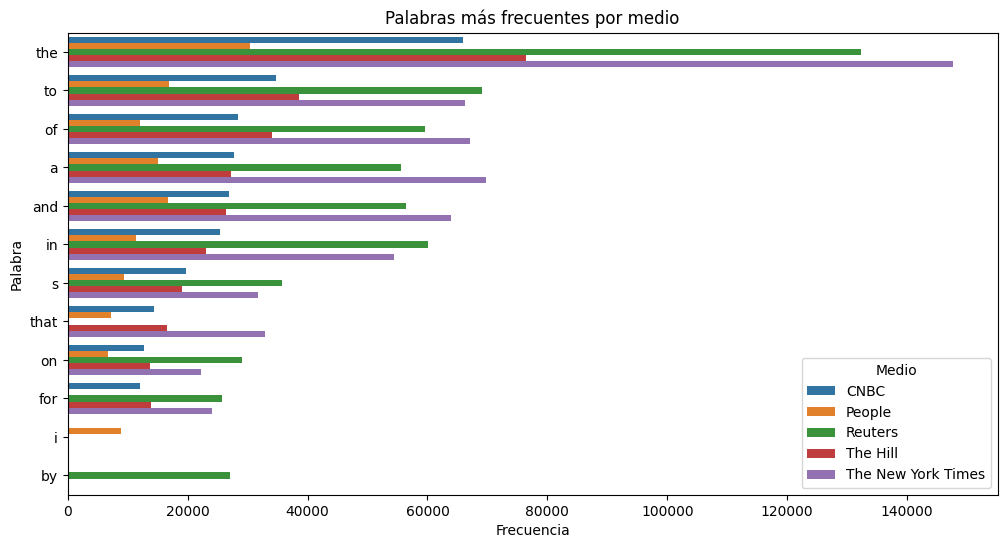

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_words,
    x="frequency",
    y="words",
    hue="publication"
)

plt.title("Palabras más frecuentes por medio")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")
plt.legend(title="Medio")
plt.show()

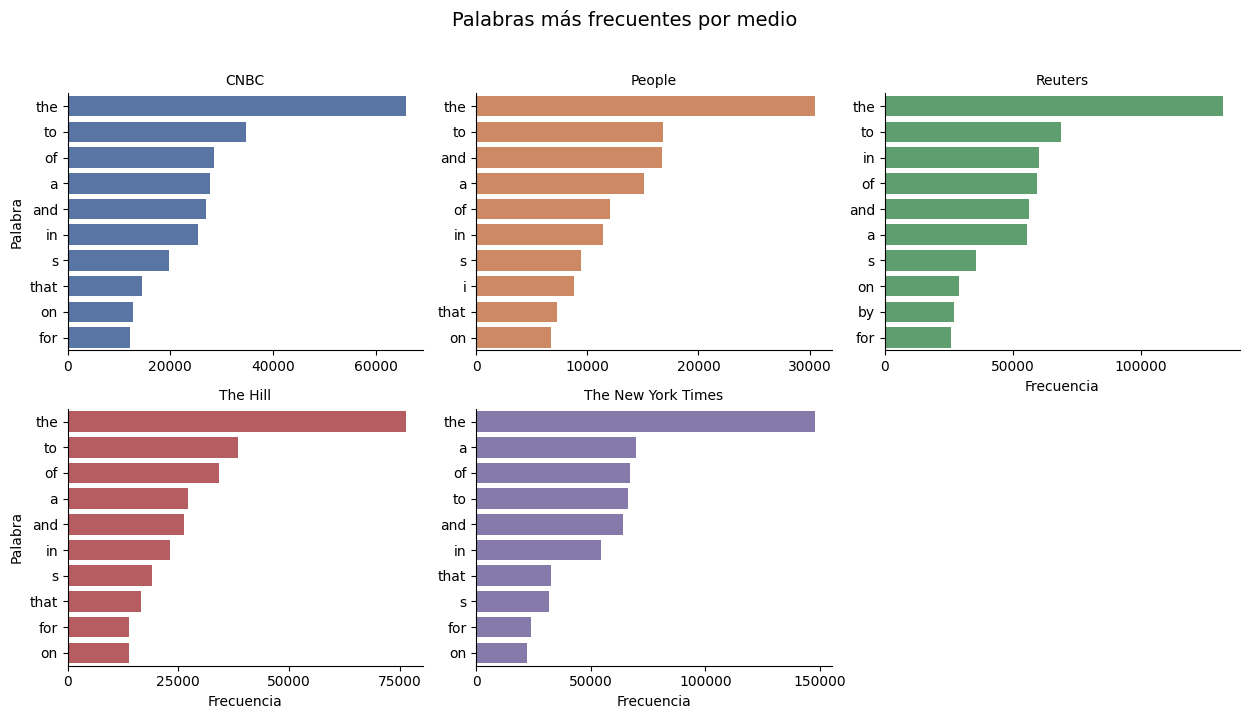

In [ ]:
palette = {
    "The New York Times": "#8172B2",
    "Reuters":            "#55A868",
    "The Hill":           "#C44E52",
    "CNBC":               "#4C72B0",
    "People":             "#DD8452",
}

g = sns.catplot(
    data=top_words,
    x="frequency",
    y="words",
    col="publication",
    hue="publication",
    palette=palette,
    kind="bar",
    col_wrap=3,
    sharey=False,
    sharex=False,
    height=3.5,
    aspect=1.2,
    legend=False,
)

g.set_titles("{col_name}")
g.set_axis_labels("Frecuencia", "Palabra")
g.fig.suptitle("Palabras más frecuentes por medio", y=1.02, fontsize=14)

for ax in g.axes.flat:
    ax.locator_params(axis='x', nbins=4)

plt.tight_layout()
plt.show()

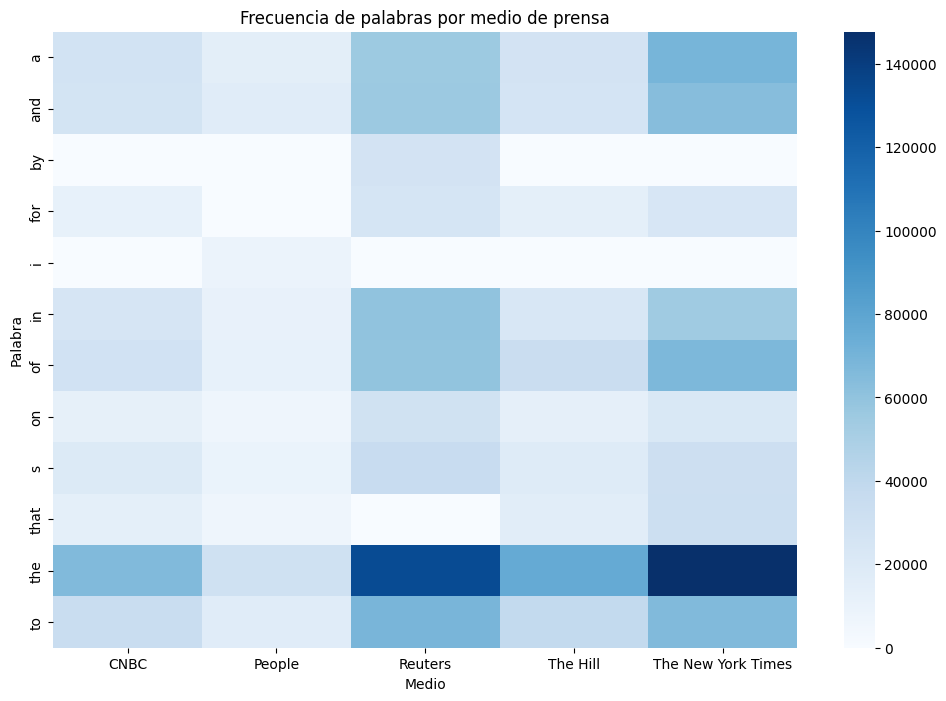

In [ ]:
# Pivotear datos
heatmap_data = top_words.pivot(
    index="words",
    columns="publication",
    values="frequency"
)

# Reemplazar NaN por 0
heatmap_data = heatmap_data.fillna(0)

# Crear figura
plt.figure(figsize=(12,8))

# Heatmap
sns.heatmap(
    heatmap_data,
    cmap="Blues",
    fmt=".0f"
)

plt.title("Frecuencia de palabras por medio de prensa")
plt.xlabel("Medio")
plt.ylabel("Palabra")

plt.show()

El gráfico presenta las palabras más frecuentes utilizadas por cada uno de los cinco medios de prensa. Tal como está, la interpretación es limitada debido a la presencia de stopwords, es decir, palabras muy frecuentes del idioma inglés que no aportan contenido informativo relevante.

Una mejora necesaria sería la eliminación de estas stopwords antes del análisis, lo que permitiría identificar con mayor claridad el vocabulario característico de cada medio.

A partir de esta base, la visualización podría complementarse con la incorporación de filtros adicionales. Por ejemplo, se podría segmentar por temática para comparar las palabras más frecuentes entre medios dentro de un mismo tema. También se podría agrupar los datos por períodos temporales (mensuales o anuales) para analizar variaciones en el lenguaje utilizado a lo largo del tiempo.

### Limpieza de Stopwords



In [ ]:
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))

print(stop_words)

{'am', 'did', 'can', 'him', 'from', 'your', "i'm", 'nor', 'on', 'who', "we've", 'its', 'where', "they're", 'no', "they've", 'having', 'up', "they'll", "didn't", 'ma', 'had', "you'd", 'our', 'again', 'themselves', 'been', 'very', "wouldn't", 'between', "don't", 'i', 'further', 'her', 'yourself', 'just', 'after', 'm', 'yourselves', 'out', "couldn't", 'won', 'be', 'so', 'those', 'through', "we'd", 'now', 'is', 'to', 'ain', 'down', 'needn', 'me', 'mightn', 'when', 'more', 'into', "wasn't", 'y', 'too', 'didn', 'was', 'were', 'any', 'at', 'about', "i'd", 'doing', 'same', 'couldn', 'weren', 'does', 'doesn', 'herself', 'few', "i'll", 'which', 'the', 'than', 're', 'them', 'other', 'above', 'isn', 'aren', "shan't", 'while', 'being', "weren't", 'you', 'this', 'by', "needn't", 'not', "that'll", 'against', 'itself', 'once', 'why', 'off', 'hasn', 'if', "she'll", 'his', "won't", 'whom', 'they', 'until', 'over', 'during', "it's", 'because', 'do', 'he', 'will', "you've", "aren't", 'haven', 'shan', 'don

In [ ]:
# Quita las stopwords, abreviaturas de títulos y palabras de una letra (a, y, o)
df_sinSW = df_exploded[
    (~df_exploded["words"].isin(stop_words.union({"mr", "ms", "mrs", "miss"}))) &
    (df_exploded["words"].str.len() > 1)
]

In [ ]:
df_counts2 = (
    df_sinSW
    .groupby(["publication", "words"])
    .size()
    .reset_index(name="frequency")
)

top_words2 = (
    df_counts2
    .sort_values(
        ["publication", "frequency"],
        ascending=[True, False]
    )
    .groupby("publication")
    .head(10)
    .reset_index(drop=True)
)

print(top_words2)

           publication       words  frequency
0                 CNBC        said       9767
1                 CNBC        year       3888
2                 CNBC     percent       3857
3                 CNBC       would       2929
4                 CNBC        also       2784
5                 CNBC     company       2715
6                 CNBC         new       2686
7                 CNBC      market       2610
8                 CNBC       trump       2470
9                 CNBC         one       2278
10              People      people       2530
11              People        said       2402
12              People         one       1667
13              People        like       1558
14              People        time       1481
15              People         new       1397
16              People        says       1363
17              People        also       1267
18              People        year       1254
19              People        told       1228
20             Reuters        said

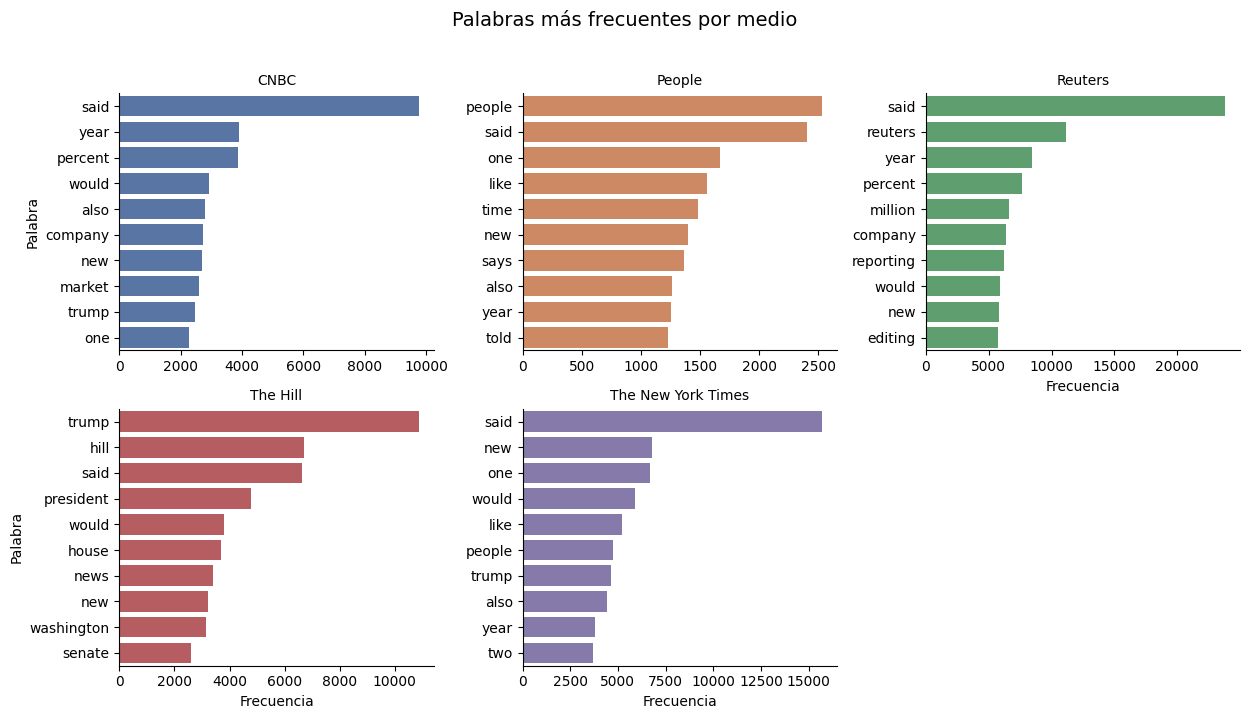

In [ ]:
palette = {
    "The New York Times": "#8172B2",
    "Reuters":            "#55A868",
    "The Hill":           "#C44E52",
    "CNBC":               "#4C72B0",
    "People":             "#DD8452",
}

g = sns.catplot(
    data=top_words2,
    x="frequency",
    y="words",
    col="publication",
    hue="publication",
    palette=palette,
    kind="bar",
    col_wrap=3,
    sharey=False,
    sharex=False,
    height=3.5,
    aspect=1.2,
    legend=False,
)

g.set_titles("{col_name}")
g.set_axis_labels("Frecuencia", "Palabra")
g.fig.suptitle("Palabras más frecuentes por medio", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Al eliminar las stopwords, podemos visualizar con más claridad los términos característicos de cada medio y, en cierta forma, su enfoque editorial.

Por ejemplo, en The Hill, destacan términos claramente políticos como “trump”, “president”, “house”, “senate” y “washington”. Esto indica un enfoque en temas políticos, con énfasis en instituciones y figuras del gobierno de Estados Unidos.

Por otro lado, en CNBC, aparecen palabras asociadas a economía y mercados como “percent”, “company”, “market” y “year”, lo que refleja un perfil más financiero y económico.

En conjunto, estas diferencias en el vocabulario permiten distinguir el tipo de contenido que predomina en cada medio.

## B. Medios con mayor cantidad de palabras


In [ ]:
df_top5['n_palabras'] = df_top5['CleanText'].astype(str).str.split().str.len()

total_palabras = df_top5.groupby('publication')['n_palabras'].sum().sort_values(ascending=False)

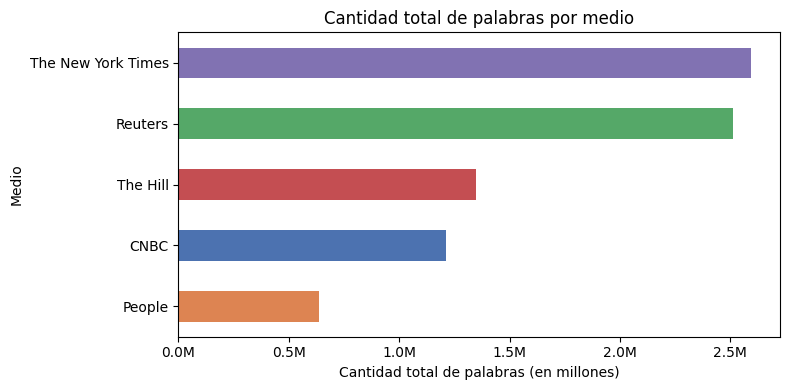

In [ ]:
palette = [
    "#8172B2",
    "#55A868",
    "#C44E52",
    "#4C72B0",
    "#DD8452",
]

total_palabras.plot(kind='barh', figsize=(8, 4),color=palette[:len(total_palabras)])
plt.xlabel('Cantidad total de palabras (en millones)')
plt.ylabel('Medio')
plt.title('Cantidad total de palabras por medio')
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Cantidad de artículos por medio
print("Artículos por medio:")
print(df_top5['publication'].value_counts())

df_top5['n_palabras'] = df_top5['CleanText'].astype(str).str.split().str.len()

total_palabras = df_top5.groupby('publication')['n_palabras'].sum().sort_values(ascending=False)
print(total_palabras)

Artículos por medio:
publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528
Name: count, dtype: int64
publication
The New York Times    2595606
Reuters               2512584
The Hill              1348007
CNBC                  1212989
People                 635148
Name: n_palabras, dtype: int64


El gráfico muestra la cantidad total de palabras utilizadas por cada medio. Sin embargo, esta medida no permite concluir qué medio escribe artículos más extensos, ya que depende directamente de la cantidad de artículos que publica cada uno.

Por ejemplo, The New York Times y Reuters presentan valores totales de palabras similares, pero Reuters cuenta con 9431 artículos frente a los 2840 de NYT. Esto implica que, en promedio, los artículos del New York Times son más largos, mientras que Reuters tiende a publicar una mayor cantidad de artículos más breves.

Para una comparación más adecuada, resulta más informativo analizar el promedio de palabras por artículo en lugar del total. Esta métrica permite evaluar de forma más equilibrada la longitud media de los artículos en cada medio. Esto puede observarse en la siguiente tabla:

In [ ]:
promedio = df_top5.groupby('publication')['n_palabras'].mean().sort_values(ascending=False)
print("\nPromedio de palabras por artículo:")
print(promedio.round(0))


Promedio de palabras por artículo:
publication
The New York Times    914.0
The Hill              574.0
CNBC                  462.0
People                416.0
Reuters               266.0
Name: n_palabras, dtype: float64


## C. Matriz de menciones entre medios

In [ ]:
# Construya una matriz de 5x5, donde cada fila y columna corresponden a un medio de prensa,
# y la entrada (i,j) contiene la cantidad de veces que el medio "i" menciona al medio "j".

df_top5["publication"] = df_top5["publication"].str.lower()
medios = df_top5["publication"].unique()

mentions_matrix = pd.DataFrame(0, index=medios, columns=medios)

df_top5["CleanText"] = df_top5["CleanText"].astype(str)

for i in medios:
    textos_i = df_top5.loc[df_top5["publication"] == i, "CleanText"]

    for j in medios:
        pattern = rf"\b{j}\b"   # palabra completa

        mentions_matrix.loc[i, j] = textos_i.str.count(pattern).sum()

print(mentions_matrix)

# People genera ruido porque los articulos estan en ingles. La diagonal pueden ser automenciones, citas, URL, firmas al final del cuerpo


                    reuters  cnbc  the hill  the new york times  people
reuters               11183    44         2                  37    2832
cnbc                   1200  1790         6                  53    1826
the hill                123    20      3558                 145    2009
the new york times       54    19        19                 657    4731
people                    7     5         4                  39    2530


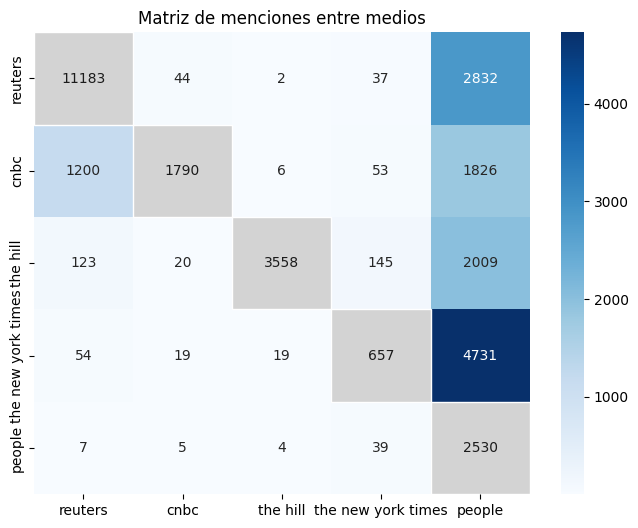

In [ ]:
plt.figure(figsize=(8,6))

data_for_colors = mentions_matrix.copy().astype(float)
np.fill_diagonal(data_for_colors.values, np.nan)

# Heatmap
ax = sns.heatmap(
    data_for_colors,
    cmap="Blues",
    annot=mentions_matrix,
    fmt=".0f"
)

n = len(mentions_matrix)

# pintar diagonal gris (fondo)
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (i, i),
            1, 1,
            facecolor="lightgray",
            edgecolor="white",
            zorder=1
        )
    )

    ax.text(i + 0.5, i + 0.5, f"{mentions_matrix.iloc[i, i]:.0f}",
            ha='center', va='center',
            color='#1B1B1B', zorder=10)

plt.title("Matriz de menciones entre medios")
plt.show()

Para visualizar mejor la matriz de menciones entre medios se realizó un mapa de calor, excluyendo del análisis la diagonal, ya que estos valores pueden referir tanto a automenciones, URLs, firmas, entre otros. Observando este mapa de calor, lo que más destaca son las menciones al medio People, pero como se mencionó anteriormente, esto debe tomarse con precaución, ya que “People” es una palabra común en inglés y no necesariamente indica una mención al medio. Entre los demás medios, se observa que CNBC menciona con frecuencia a Reuters, mientras que The Hill destaca por sus menciones a Reuters y a The New York Times. Las menciones cruzadas entre los otros medios son más limitadas, mostrando que la mayoría de interacciones se concentran en estos casos.

Para reducir el error al analizar las menciones al medio People, se podría tener en cuenta las mayúsculas para contabilizar únicamente “People” como nombre propio. No obstante, este enfoque seguiría generando ruido, ya que cualquier oración que comience con la palabra “People” también inicia con mayúscula.

Por otro lado, se realizó un grafo de menciones entre medios para visualizar con mayor claridad las relaciones identificadas anteriormente. En este gráfico, cada nodo representa un medio de prensa y las aristas indican las menciones entre ellos. Además, el grosor de las aristas varía según la cantidad de menciones registradas, mientras que la dirección de la flecha indica el sentido de la mención.

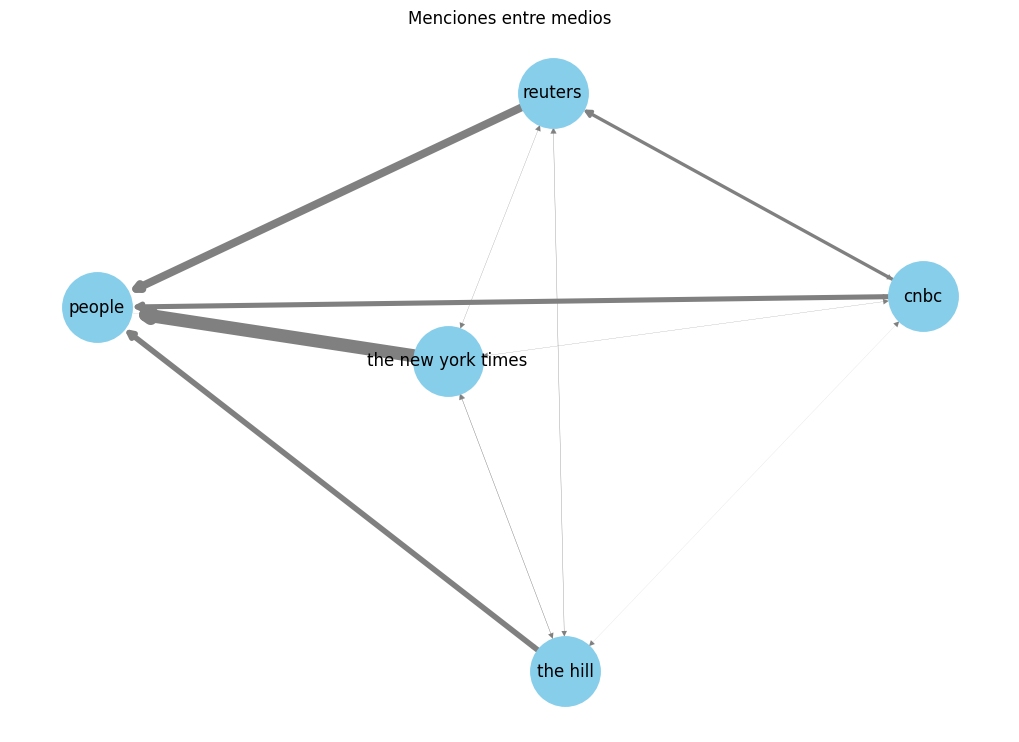

In [ ]:
G = nx.from_pandas_adjacency(mat, create_using=nx.DiGraph)

plt.figure(figsize=(10,7))

pos = nx.spring_layout(G, seed=42)

edges = G.edges(data=True)
weights = [d["weight"] for (_, _, d) in edges]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="skyblue",
    edge_color="gray",
    width=[w/500 for w in weights],
    arrows=True
)

plt.title("Menciones entre medios")
plt.axis("off")
plt.show()

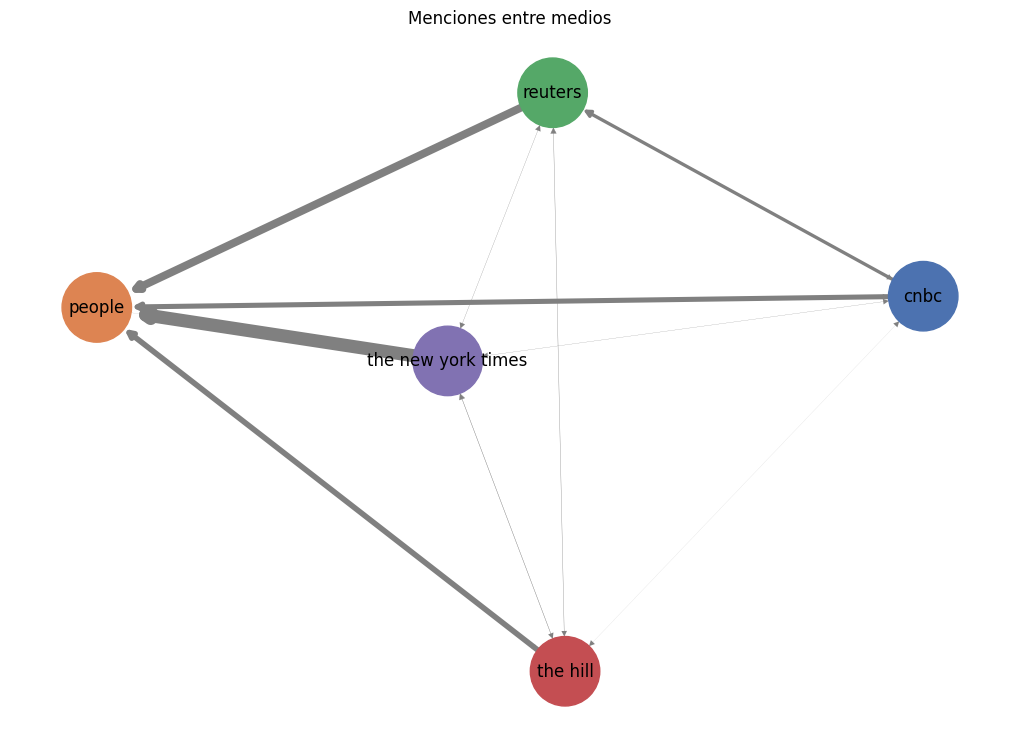

In [ ]:
palette = {
    "the new york times": "#8172B2",
    "reuters":            "#55A868",
    "the hill":           "#C44E52",
    "cnbc":               "#4C72B0",
    "people":             "#DD8452",
}

G = nx.from_pandas_adjacency(mat, create_using=nx.DiGraph)

plt.figure(figsize=(10,7))

pos = nx.spring_layout(G, seed=42)

edges = G.edges(data=True)
weights = [d["weight"] for (_, _, d) in edges]

# Color de cada nodo según el medio
node_colors = [palette.get(node, "lightgray") for node in G.nodes()]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color=node_colors,
    edge_color="gray",
    width=[w/500 for w in weights],
    arrows=True
)

plt.title("Menciones entre medios")
plt.axis("off")
plt.show()

## D. Preguntas propuestas

1) ¿Es posible predecir a qué sección pertenece un artículo a partir de su contenido?

Esto podría abordarse mediante un análisis supervisado utilizando el cuerpo del artículo como variable de entrada y la sección como variable objetivo. Usando técnicas de procesamiento de lenguaje natural, se podrían entrenar modelos para clasificar automáticamente nuevos artículos en una categoría temática.

Aunque la variable section contiene una gran cantidad de valores faltantes, los artículos que sí cuentan con esta información podrían utilizarse para entrenar el modelo. Una vez entrenado, el modelo podría asignar una sección a los artículos que actualmente no la tienen. No obstante, la alta proporción de valores faltantes reduce la cantidad de datos disponibles para el entrenamiento, lo que podría afectar el rendimiento del modelo.

2) ¿Existe una relación entre los autores y los medios de prensa en los que publican?

Se podría analizar la distribución de autores por medio para identificar si cada uno trabaja principalmente en una sola publicación o si existen autores compartidos entre distintos medios. Esto permitiría estudiar posibles patrones de exclusividad o colaboración entre medios.

3) ¿Se pueden identificar noticias sensacionalistas a partir del lenguaje que utilizan?

Se podría analizar si ciertos patrones lingüísticos están asociados a un estilo más “amarillista”, como el uso de palabras emocionalmente cargadas, adjetivos extremos o estructuras de títulos llamativas. A partir de esto, se podrían construir indicadores simples, como la frecuencia de ciertos términos o el uso de signos de exclamación, para evaluar qué artículos presentan un tono más sensacionalista dentro de cada medio.

## Notas:

Durante la elaboración de este trabajo se utilizó inteligencia artificial como herramienta de apoyo en distintos aspectos técnicos del proyecto, principalmente para el desarrollo y corrección de código, comprensión de errores, manejo de conflictos entre dependencias y mejora de visualizaciones.
Su utilización fue especialmente útil dado que únicamente contábamos con experiencia previa en R y estamos en proceso de aprendizaje de Python.

## Repositorio en github

